In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
df=pd.read_csv('drug200(DT).csv')

In [58]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [59]:
df.tail()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX
199,40,F,LOW,NORMAL,11.349,drugX


In [60]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [62]:
df.shape

(200, 6)

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


<Axes: >

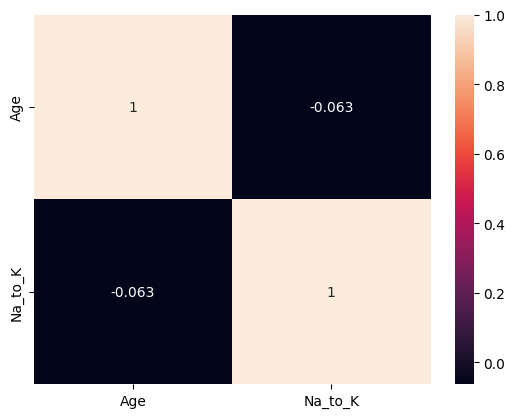

In [65]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [66]:
df['Drug'].unique()

array(['drugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [67]:
df['Drug'].value_counts()

,count
Drug,
drugY,91
drugX,54
drugA,23
drugC,16
drugB,16


<Axes: xlabel='Drug', ylabel='Count'>

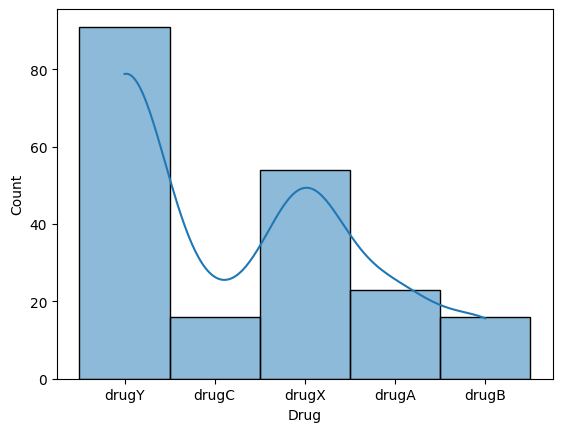

In [68]:
sns.histplot(df['Drug'],bins=30,kde=True)

<Axes: xlabel='Na_to_K', ylabel='Count'>

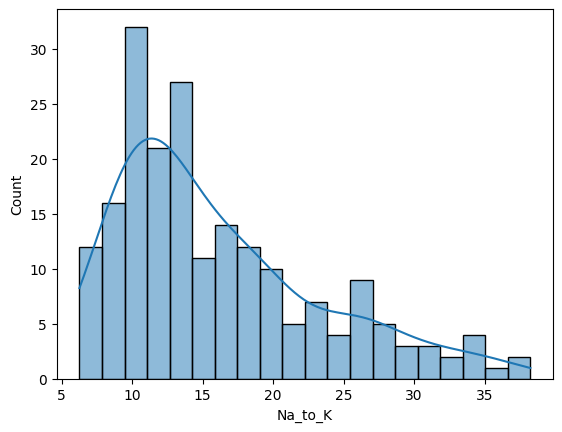

In [69]:
sns.histplot(df['Na_to_K'],bins=20,kde=True)

(array([12., 16., 32., 21., 27., 11., 14., 12., 10.,  5.,  7.,  4.,  9.,
         5.,  3.,  3.,  2.,  4.,  1.,  2.]),
 array([ 6.269 ,  7.8679,  9.4668, 11.0657, 12.6646, 14.2635, 15.8624,
        17.4613, 19.0602, 20.6591, 22.258 , 23.8569, 25.4558, 27.0547,
        28.6536, 30.2525, 31.8514, 33.4503, 35.0492, 36.6481, 38.247 ]),
 <BarContainer object of 20 artists>)

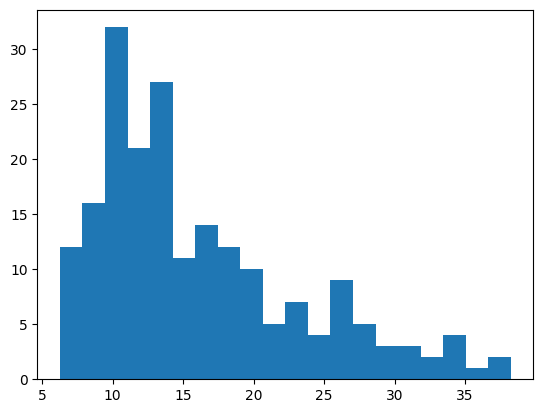

In [70]:
plt.hist(df['Na_to_K'],bins=20)

<Axes: xlabel='Drug', ylabel='Na_to_K'>

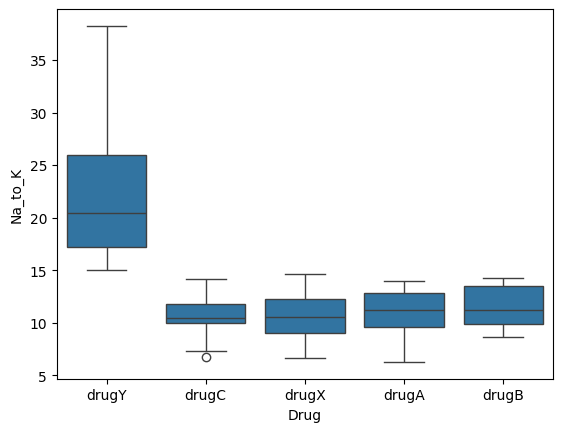

In [71]:
sns.boxplot(y='Na_to_K',x='Drug',data=df)

In [72]:
col=['Sex','BP','Cholesterol','Drug']
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in  col:
  df[i] = le.fit_transform(df[i])


In [73]:
X=df.drop('Drug',axis=1)
y=df['Drug']

In [74]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4


In [75]:
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [76]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [77]:
X_train

,Age,Sex,BP,Cholesterol,Na_to_K
79,32,0,1,1,10.840
197,52,1,2,0,9.894
38,39,0,2,1,9.709
24,33,0,1,0,33.486
122,34,1,2,0,22.456
...,...,...,...,...,...
106,22,1,2,0,11.953
14,50,0,2,0,12.703
92,29,0,0,0,29.450
179,67,0,2,0,15.891


In [78]:
X_test

,Age,Sex,BP,Cholesterol,Na_to_K
95,36,1,1,1,11.424
15,16,0,0,1,15.516
30,18,0,2,1,8.750
158,59,0,1,0,10.444
128,47,1,1,1,33.542
115,51,1,0,0,18.295
69,18,0,0,1,24.276
170,28,0,2,0,12.879
174,42,1,0,1,12.766
45,66,0,2,1,8.107


In [98]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(X_train_scaled,y_train)


LogisticRegression()

In [99]:
from sklearn.metrics import accuracy_score

In [101]:
y_pred=lg.predict(X_train)
accuracy_score(y_train,y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.525

In [102]:
y_pred=lg.predict(X_test)
accuracy_score(y_test,y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.45

In [103]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier(min_samples_split=5,
                            min_samples_leaf=2,
                            max_depth=3,
                            criterion= 'entropy')


In [104]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=2,
                       min_samples_split=5)

In [105]:
y_pred=dtc.predict(X_train)
accuracy_score(y_train,y_pred)

0.93125

In [106]:
y_pred=dtc.predict(X_test)
accuracy_score(y_test,y_pred)

0.875

In [107]:
from sklearn.model_selection import RandomizedSearchCV

In [108]:
param_grid={
    'max_depth':[3,5,7],
    'min_samples_split':[5,10,15],
    'min_samples_leaf':[2,5,10],
    'criterion':['gini','entropy']
}

In [109]:
random_search = RandomizedSearchCV(
    estimator=dtc,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42)
random_search.fit(X_train,y_train)

RandomizedSearchCV(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=3,
                                                    min_samples_leaf=2,
                                                    min_samples_split=5),
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7],
                                        'min_samples_leaf': [2, 5, 10],
                                        'min_samples_split': [5, 10, 15]},
                   random_state=42, scoring='accuracy')

In [110]:
random_search.best_params_

{'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 7,
 'criterion': 'gini'}

In [111]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [112]:
rfc_param ={
    'n_estimators':[50,100,150],
    'max_depth':[3,5,7,9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':['sqrt','log2']
}

In [113]:
from sklearn.model_selection import GridSearchCV
rfc_search = GridSearchCV(rfc,rfc_param,cv=5)

In [114]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [115]:
rfc_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 7, 9],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]})

In [116]:
from sklearn.metrics import accuracy_score
y_pred=rfc.predict(X_train)
accuracy_score(y_train,y_pred)

1.0

In [117]:
y_pred=rfc.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [121]:
best_model = rfc_search.best_estimator_

In [122]:
import pickle

with open('drug_model.pkl', 'wb') as fs:
    pickle.dump(best_model, fs)
